# Ejercicio 4 - Analisis temporal de cianobacteria

Este cuaderno resume y visualiza la evolucion temporal del indice de
cianobacteria de los lagos Atitlan y Amatitlan a partir del manifiesto
`data/processed/manifest_indices.csv` generado en el ejercicio anterior.

El cuaderno primero valida ese manifiesto y reporta cuantas de las 22
escenas oficiales ya tienen un raster de cianobacteria calculado. Solo
resume, grafica e interpreta lo que ya esta listo: ninguna fila pendiente
se completa manualmente aqui, y ningun raster se corrige dentro de este
cuaderno.

## 1. Criterio de "pico" (definido antes de mirar los datos)

Una fecha se marca como pico si su promedio de cianobacteria supera en una
desviacion estandar (`PICO_DESVIACIONES` en `src/config.py`) el promedio de
la propia serie del lago. La media y la desviacion de referencia se
calculan solo con fechas de cobertura completa (`quality_flag ==
"calculado"`); las fechas de cobertura parcial se evaluan contra ese mismo
umbral pero no participan en calcularlo.

Este es un umbral descriptivo y repetible, no un modelo de series de
tiempo: cada lago tiene solo 11 observaciones irregulares, insuficientes
para estacionalidad o tendencias estadisticamente robustas.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
if not (ROOT / 'src').is_dir():
    raise RuntimeError('Abra Jupyter desde la raiz de Laboratorio 4')

sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import display

from src import analisis_temporal as at
from src.config import PICO_DESVIACIONES

print(f'Raiz del proyecto: {ROOT}')
print(f'Umbral de pico: media + {PICO_DESVIACIONES} desviaciones estandar')


Raiz del proyecto: C:\Users\anna2\Desktop\data-science-lab-4-datos-geoespaciales
Umbral de pico: media + 1.0 desviaciones estandar


## 2. Estado del manifiesto de indices

Cuenta cuantas de las 22 escenas oficiales de cianobacteria estan listas
(raster exportado, `quality_flag` distinto de `pendiente_calculo`) y
cuales siguen pendientes del calculo de indices.

In [2]:
report = at.pending_report()
print(f"Cianobacteria lista: {report['listas']}/{report['total_escenas']} escenas")
print(f"Pendientes: {report['pendientes']}")

pendientes = pd.DataFrame(report['fechas_pendientes'], columns=['lago', 'fecha'])
if not pendientes.empty:
    display(pendientes.groupby('lago').size().rename('fechas_pendientes').to_frame())


Cianobacteria lista: 22/22 escenas
Pendientes: 0


## 3. Validacion del manifiesto

No se corrige ninguna fila aqui: si una fila lista le falta unidad, dtype,
pixeles validos o cobertura, la funcion lanza un error explicito y ese
raster debe corregirse en el calculo de indices, no en este cuaderno.

In [3]:
at.validate_indices_manifest_ready()
print('Manifiesto de indices valido para las filas ya calculadas.')


Manifiesto de indices valido para las filas ya calculadas.


## 4. Resumen temporal

Construye una fila por lago y fecha con el promedio, la mediana, la
desviacion estandar y la cobertura valida de cianobacteria, leyendo
directamente los GeoTIFF declarados en el manifiesto. Las escenas todavia
pendientes simplemente no aparecen en la tabla.

In [4]:
resumen = at.build_resumen_temporal()
resumen_df = pd.DataFrame(resumen)

if resumen_df.empty:
    print('Todavia no hay ninguna escena de cianobacteria calculada.')
    print('Esta seccion se completa automaticamente cuando existan raster listos.')
else:
    display(resumen_df)
    path = at.write_resumen_temporal(resumen)
    print(f'resumen_temporal.csv escrito con {len(resumen)} filas en {path}')


,lago,fecha,cyano_promedio,cyano_mediana,cyano_std,pixeles_validos,cobertura_valida_pct,quality_flag
0,amatitlan,2025-01-28,4.422046,4.486700,0.981161,146549,11.7510,calculado
1,amatitlan,2025-04-15,4.530264,4.592442,1.350800,144874,11.6167,calculado
2,amatitlan,2025-04-28,5.747513,4.891471,2.883925,144882,11.6173,calculado
3,amatitlan,2025-11-24,4.667747,4.009678,5.612466,145910,11.6998,calculado
4,amatitlan,2026-01-08,6.673856,4.893932,8.366568,146638,11.7581,calculado
5,amatitlan,2026-02-02,4.284474,4.402147,0.756131,143853,11.5348,calculado
6,amatitlan,2026-02-07,4.302241,4.454119,0.746261,146153,11.7192,cobertura_parcial_oficial
7,amatitlan,2026-03-29,6.429644,5.246593,3.954471,146526,11.7492,calculado
8,amatitlan,2026-04-13,6.742288,6.414774,1.620667,147210,11.8040,calculado
9,amatitlan,2026-04-28,9.909293,6.436383,7.465031,139711,11.2027,calculado


resumen_temporal.csv escrito con 22 filas en C:\Users\anna2\Desktop\data-science-lab-4-datos-geoespaciales\data\processed\tablas\resumen_temporal.csv


## 5. Grafico de linea por lago

Una serie por lago, ordenada cronologicamente. Los picos (criterio de la
seccion 1) se marcan con un triangulo y las fechas de cobertura parcial se
marcan con una equis, para que no se lean con la misma confiabilidad que
una escena completa.

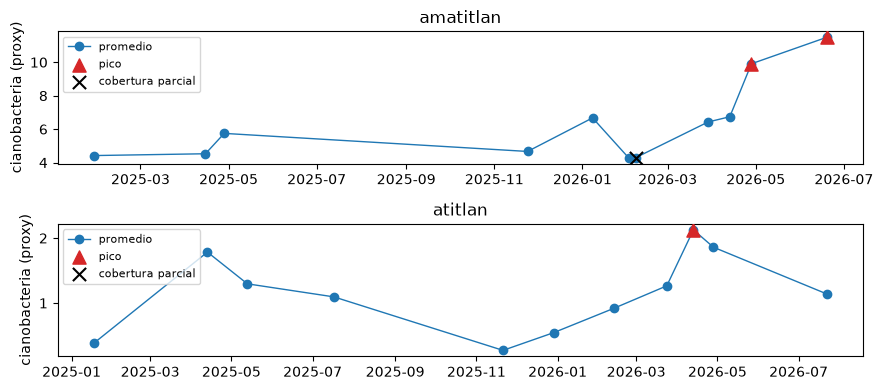

In [5]:
if resumen_df.empty:
    print('Sin datos todavia: no se puede graficar.')
else:
    import matplotlib.pyplot as plt

    flagged = pd.DataFrame(at.flag_peaks(resumen))
    flagged['fecha'] = pd.to_datetime(flagged['fecha'])
    flagged = flagged.sort_values(['lago', 'fecha'])

    fig, axes = plt.subplots(len(flagged['lago'].unique()), 1, figsize=(9, 4), squeeze=False, sharex=False)
    for ax, (lago, serie) in zip(axes[:, 0], flagged.groupby('lago')):
        ax.plot(serie['fecha'], serie['cyano_promedio'], marker='o', linewidth=1, label='promedio')

        picos = serie[serie['es_pico']]
        ax.scatter(picos['fecha'], picos['cyano_promedio'], marker='^', color='tab:red', s=90, zorder=3, label='pico')

        parciales = serie[serie['quality_flag'] == 'cobertura_parcial_oficial']
        ax.scatter(parciales['fecha'], parciales['cyano_promedio'], marker='x', color='black', s=90, zorder=3, label='cobertura parcial')

        ax.set_title(lago)
        ax.set_ylabel('cianobacteria (proxy)')
        ax.legend(loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()


## 6. Comparacion conjunta

Los dos lagos usan el mismo indice, la misma formula y la misma unidad
(mismo script de cianobacteria, misma version), por lo que es valido
compararlos en un solo eje.

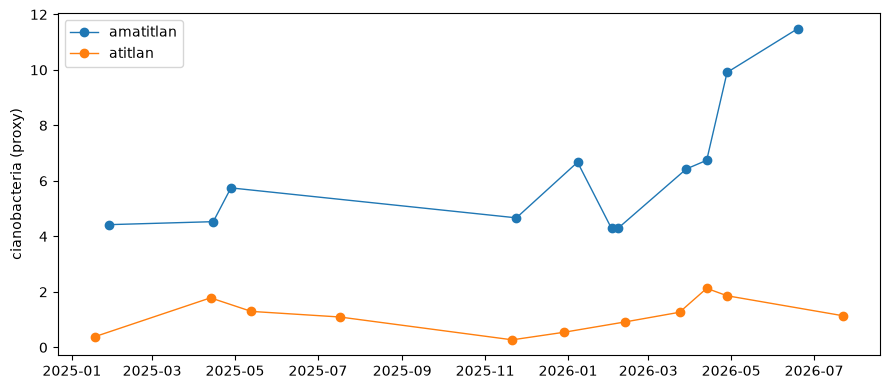

In [6]:
if resumen_df.empty:
    print('Sin datos todavia: no se puede comparar.')
else:
    fig, ax = plt.subplots(figsize=(9, 4))
    for lago, serie in flagged.groupby('lago'):
        ax.plot(serie['fecha'], serie['cyano_promedio'], marker='o', linewidth=1, label=lago)
    ax.set_ylabel('cianobacteria (proxy)')
    ax.legend()
    plt.tight_layout()
    plt.show()


## 7. Cobertura y confiabilidad

Cobertura valida por fecha; la fila de Amatitlan `2026-02-07` debe
mantenerse marcada como cobertura parcial y no leerse con la misma
confiabilidad que el resto de la serie.

In [7]:
if resumen_df.empty:
    print('Sin datos todavia.')
else:
    display(resumen_df[['lago', 'fecha', 'cobertura_valida_pct', 'quality_flag']])


,lago,fecha,cobertura_valida_pct,quality_flag
0,amatitlan,2025-01-28,11.7510,calculado
1,amatitlan,2025-04-15,11.6167,calculado
2,amatitlan,2025-04-28,11.6173,calculado
3,amatitlan,2025-11-24,11.6998,calculado
4,amatitlan,2026-01-08,11.7581,calculado
5,amatitlan,2026-02-02,11.5348,calculado
6,amatitlan,2026-02-07,11.7192,cobertura_parcial_oficial
7,amatitlan,2026-03-29,11.7492,calculado
8,amatitlan,2026-04-13,11.8040,calculado
9,amatitlan,2026-04-28,11.2027,calculado


## 8. Interpretacion

**Observado directamente en los datos:**

- Amatitlan muestra una tendencia al alza en la segunda mitad de la serie: de
  valores entre 4.3 y 4.7 (enero 2025 a febrero 2026) sube a 6.4-6.7 en
  marzo-abril de 2026 y llega a 9.9 y 11.5 en las dos ultimas fechas
  (28-abr-2026 y 19-jun-2026), ambas marcadas como pico por el criterio
  definido en la seccion 1 (superan la media + 1 desviacion estandar del
  resto de la serie).
- Atitlan se mantiene en un rango mucho mas bajo durante toda la serie
  (0.27 a 2.13), sin una tendencia sostenida de aumento o disminucion. El
  unico pico identificado (13-abr-2026, 2.13) supera el umbral (2.00) por un
  margen pequeno.
- 6 de las 11 fechas de Atitlan quedaron marcadas `revisar_valores_atipicos`
  (mas del 10% de los pixeles validos fuera del rango de referencia 0-500
  ug/L del script), frente a ninguna en Amatitlan.

**Posible explicacion ambiental:**

- El aumento en Amatitlan hacia abril-junio de 2026 es temporalmente
  consistente con el inicio de la temporada de lluvias en Guatemala, que
  puede aumentar el arrastre de nutrientes hacia el lago y favorecer
  floraciones de cianobacterias; Amatitlan tiene ademas antecedentes
  documentados de eutrofizacion.
- Los valores bajos y estables de Atitlan son consistentes con un lago mas
  profundo y con menor carga de nutrientes, aunque esta comparacion no
  controla por otros factores (turbidez, viento, hora de paso del
  satelite).

**Limitaciones:**

- Son 11 observaciones irregulares por lago, no una serie regular; no se
  aplica ni se debe interpretar ningun modelo clasico de series de tiempo ni
  una estacionalidad robusta.
- La fecha de cobertura parcial de Amatitlan (2026-02-07, ~57.1% de
  cobertura valida) no tiene la misma confiabilidad que las demas; no
  participa en el calculo del umbral de pico y no debe compararse como si
  fuera una escena completa.
- Mas de la mitad de las fechas de Atitlan (6/11) estan marcadas
  `revisar_valores_atipicos`: una fraccion relevante de pixeles cae fuera
  del rango de referencia del script (0-500 ug/L), casi siempre por
  valores negativos del polinomio sobre agua muy clara. Es el mismo
  fenomeno de reflectancia casi nula en aguas profundas que ya afecto a
  NDVI/NDWI en el ejercicio 3 (ver `codebook.md` y
  `informe/secciones/03_indices.md`), no una senal ambiental real. Esto
  resta confiabilidad a leer Atitlan en terminos absolutos, aunque su
  magnitud relativa (mucho mas bajo que Amatitlan) es consistente en las
  11 fechas.
- El indice de cianobacteria es un proxy calibrado sobre un dataset
  simulado, no una medicion de laboratorio de clorofila-a; se interpreta
  como un indicador relativo entre fechas y lagos, no como una
  concentracion real.

## 9. Resultado del ejercicio

Las 22 escenas oficiales de cianobacteria estan calculadas
(`manifest_indices.csv` en `calculado`, `cobertura_parcial_oficial` o
`revisar_valores_atipicos`, sin ninguna `pendiente_calculo`).
`data/processed/tablas/resumen_temporal.csv` contiene el promedio, mediana,
desviacion estandar, pixeles validos y cobertura de las 11 fechas de cada
lago; la serie se grafico por lago con picos y cobertura parcial marcados,
mas la comparacion conjunta de la seccion 6, y la interpretacion de la
seccion 8 queda completa con las tres partes separadas.